<a href="https://colab.research.google.com/github/kwanda2426/ACML_26_P1/blob/main/new_ACML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Basic Preprocessing

In [ ]:
!pip -q install plotly scikit-learn tabulate pandas gdown

In [ ]:
# Libraries for data loading, data manipulation and data visulisation
import numpy as np
import pandas as pd

import gdown

import matplotlib.pyplot as plt
from matplotlib import rc
import seaborn as sns
import plotly.express as px
from scipy.stats import kurtosis


#Feature engineering, selection and Model training
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


#ignoring warnings
import warnings
warnings.filterwarnings('ignore')

#making sure that we can see all rows and cols
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
from tabulate import tabulate
from IPython.display import display

In [ ]:
# Reading and downloading from drive
file_id = "1deTfwvspgT545M_-ZCkHU4RqQl_b1jzp"
url = f"https://drive.google.com/uc?id={file_id}"

output = "data.csv"
gdown.download(url, output, quiet = False)

In [ ]:
# reading into a dataframe
df_main = pd.read_csv(output)
df_main.head()

In [ ]:
# Changing column names
df_main.columns = df_main.columns.str.replace(' ', '_', regex=False).str.lower()
df_main.head()

In [ ]:
df = df_main.copy()
df.shape
df.head()
df.info()
df.isnull().mean().sort_values(ascending=False)

In [ ]:
cols = ['code_gender','sk_id_curr'] + [i for i in df_main.columns if '_medi' in i] + [i for i in df_main.columns if '_mod' in i]

df_final = df_main.drop(cols, axis = 1)

In [ ]:
df_final.head()

In [ ]:
df = df_final.copy()

### Data Split

In [ ]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.3,
    stratify = y,
    random_state = 42
)

In [ ]:
!pip -q install scorecardpy

In [ ]:
train = X_train.copy()
train['target'] = y_train

test = X_test.copy()
test['target'] = y_test

In [ ]:
import scorecardpy as sc

In [ ]:
%%time
bins = sc.woebin(train, y = 'target' ,print_step = 0, check_cate_num=False)

#### IV analysis

In [ ]:
iv = sc.iv(train, y = 'target')
#iv.sort_values('info_value', ascending = False)

#### Apply WoE transform

In [ ]:
train_woe = sc.woebin_ply(train, bins)

test_woe = sc.woebin_ply(test, bins)

In [ ]:
features = [c for c in train_woe.columns if c != 'target']

X_train_woe = train_woe[features]
y_train_woe = train_woe['target']

X_test_woe = test_woe[features]
y_test_woe = test_woe['target']

#### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_woe, y_train_woe)

#### Predict

In [ ]:
lr_pred = lr.predict_proba(X_test_woe)[:,1]

In [ ]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test_woe, lr_pred)

print("Logistic Regression AUC:", auc)

#### Predictions

In [ ]:
lr_pred_proba = lr.predict_proba(X_test_woe)[:,1]

In [ ]:
lr_pred = (lr_pred_proba >= 0.5).astype(int)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test_woe, lr_pred)

print("Accuracy:", accuracy)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test_woe, lr_pred))

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_woe, lr_pred)

print(cm)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# New Preprocessing

In [1]:
!pip -q install plotly scikit-learn tabulate pandas gdown scorecardpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 1.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
# Libraries for data loading, data manipulation and data visulisation
import numpy as np
import pandas as pd

import gdown

import matplotlib.pyplot as plt
from matplotlib import rc
import seaborn as sns
import plotly.express as px
from scipy.stats import kurtosis

import scorecardpy as sc


#Feature engineering, selection and Model training
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


#ignoring warnings
import warnings
warnings.filterwarnings('ignore')

#making sure that we can see all rows and cols
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
from tabulate import tabulate
from IPython.display import display

In [3]:
# Reading and downloading from drive
file_id = "1deTfwvspgT545M_-ZCkHU4RqQl_b1jzp"
url = f"https://drive.google.com/uc?id={file_id}"

output = "data.csv"
gdown.download(url, output, quiet = False)

Downloading...
From (original): https://drive.google.com/uc?id=1deTfwvspgT545M_-ZCkHU4RqQl_b1jzp
From (redirected): https://drive.google.com/uc?id=1deTfwvspgT545M_-ZCkHU4RqQl_b1jzp&confirm=t&uuid=446af6ed-5aa8-4f40-a6c4-5744875f3963
To: /content/data.csv
100%|██████████| 166M/166M [00:03<00:00, 43.5MB/s]


'data.csv'

In [8]:
# reading into a dataframe
df = pd.read_csv(output)
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [9]:
# Remove ID Columns
df = df.drop(columns=['SK_ID_CURR'])

print(df.shape)

(307511, 121)


In [10]:
df.TARGET.value_counts()

,count
TARGET,
0,282686
1,24825


In [11]:
# Check Columns With Only One Value

low_variance = []

for col in df.columns:
    if df[col].nunique() <= 1:
        low_variance.append(col)

print(low_variance)

df = df.drop(columns=low_variance)

print(df.shape)

[]
(307511, 121)


In [12]:
# Separate numerical and categorical columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

In [13]:
#Imputation - skip
# Fill numerical missing values column by column using median
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values column by column using mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values remaining:")
print(df.isnull().sum().sum())

Missing values remaining:
0


In [14]:
# Changing column names
df.columns = df.columns.str.replace(' ', '_', regex=False).str.lower()

cols = ['code_gender'] #+ [i for i in df.columns if '_medi' in i] + [i for i in df.columns if '_mod' in i]

df_final = df.drop(cols, axis = 1)

# Data Split

In [15]:
df = df_final.copy()

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.3,
    stratify = y,
    random_state = 42
)

In [16]:
train = X_train.copy()
train['target'] = y_train

test = X_test.copy()
test['target'] = y_test

In [17]:
%%time
bins = sc.woebin(train, y = 'target' ,print_step = 0, check_cate_num=False)

[INFO] creating woe binning ...
Binning on 215257 rows and 120 columns in 00:02:17
CPU times: user 2min 6s, sys: 3.07 s, total: 2min 9s
Wall time: 2min 17s


In [18]:
train_woe = sc.woebin_ply(train, bins)

test_woe = sc.woebin_ply(test, bins)

[INFO] converting into woe values ...
Woe transformating on 215257 rows and 119 columns in 00:01:22
[INFO] converting into woe values ...
Woe transformating on 92254 rows and 119 columns in 00:00:37


In [19]:
features = [c for c in train_woe.columns if c != 'target']

X_train_woe = train_woe[features]
y_train_woe = train_woe['target']

X_test_woe = test_woe[features]
y_test_woe = test_woe['target']

# Training the Model

In [20]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

# Initialize model
lr = LogisticRegression(max_iter = 1000)

# Cross-validation evaluation
cv_scores = cross_val_score(
    lr,
    X_train_woe,
    y_train_woe,
    cv = 5,
    scoring = 'roc_auc'
)

print("Mean CV ROC AUC:", cv_scores.mean())

# Train final model on full training data
lr.fit(X_train_woe, y_train_woe)

Mean CV ROC AUC: 0.7383422648541562


LogisticRegression(class_weight='balanced', max_iter=1000)

In [21]:
lr_pred_proba = lr.predict_proba(X_test_woe)[:,1]

In [22]:
lr_pred = (lr_pred_proba >= 0.5).astype(int)

In [23]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test_woe, lr_pred)

print("Accuracy:", accuracy)

Accuracy: 0.6720684197975155


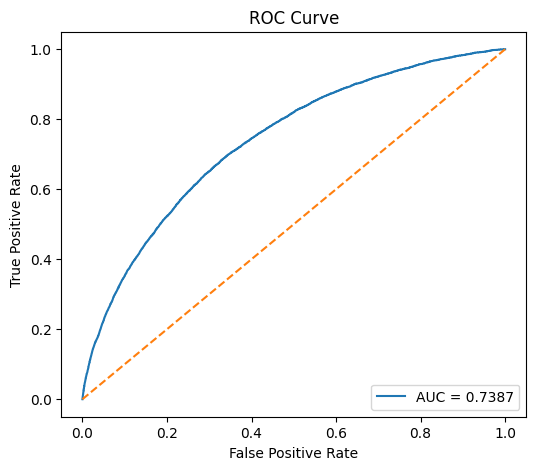

In [24]:
# Calculate ROC curve
from sklearn.metrics import roc_curve, roc_auc_score

# Predict probabilities
y_prob = lr.predict_proba(X_test_woe)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test_woe, y_prob)

# Calculate AUC
auc_score = roc_auc_score(y_test_woe, y_prob)

# Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')

plt.show()

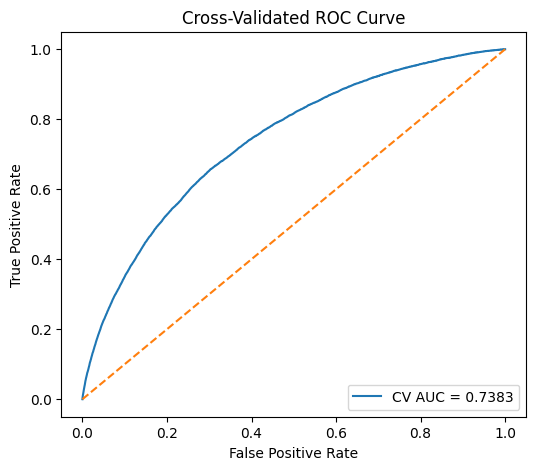

In [25]:
# Cross-validated probability predictions
from sklearn.model_selection import cross_val_predict
y_prob_cv = cross_val_predict(
    lr,
    X_train_woe,
    y_train_woe,
    cv=5,
    method='predict_proba'
)[:, 1]

# ROC + AUC
fpr, tpr, _ = roc_curve(y_train_woe, y_prob_cv)
auc_score = roc_auc_score(y_train_woe, y_prob_cv)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'CV AUC = {auc_score:.4f}')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Cross-Validated ROC Curve')
plt.legend(loc='lower right')

plt.show()

# Undersampling